In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV


In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#memuat dataset

data=pd.read_csv('D:\kuliah\kuliah\Bimkar\diabetes.csv', na_values=' ?')

**1. Menampilkan beberapa baris pertama dan informasi umum dataset**

In [4]:

print("Beberapa baris pertama dataset:")
print(data.head())

print("\nInformasi Umum Dataset:")
data_info = data.info()
data.dtypes


Beberapa baris pertama dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               7

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Dataset ini berisi 768 data dengan 9 variabel yang seluruhnya bertipe numerikal. Tidak terdapat nilai kosong (null), namun beberapa variabel medis seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak realistis. Nilai-nilai tersebut kemungkinan merepresentasikan data yang hilang, sehingga perlu ditangani pada tahap preprocessing.

Variabel Outcome merupakan target klasifikasi biner, di mana nilai 1 menunjukkan pasien menderita diabetes dan nilai 0 menunjukkan pasien tidak menderita diabetes. Sementara itu, fitur lain seperti Pregnancies dan Age bersifat numerikal diskrit, dan fitur medis lainnya bersifat numerikal kontinu.

Secara keseluruhan, dataset ini sudah cukup rapi dan siap digunakan untuk pemodelan machine learning, dengan catatan diperlukan penyesuaian awal seperti penanganan nilai nol yang tidak valid serta normalisasi data sebelum proses training model dilakukan.

**2. Analisis Statistik & Visualisasi.**

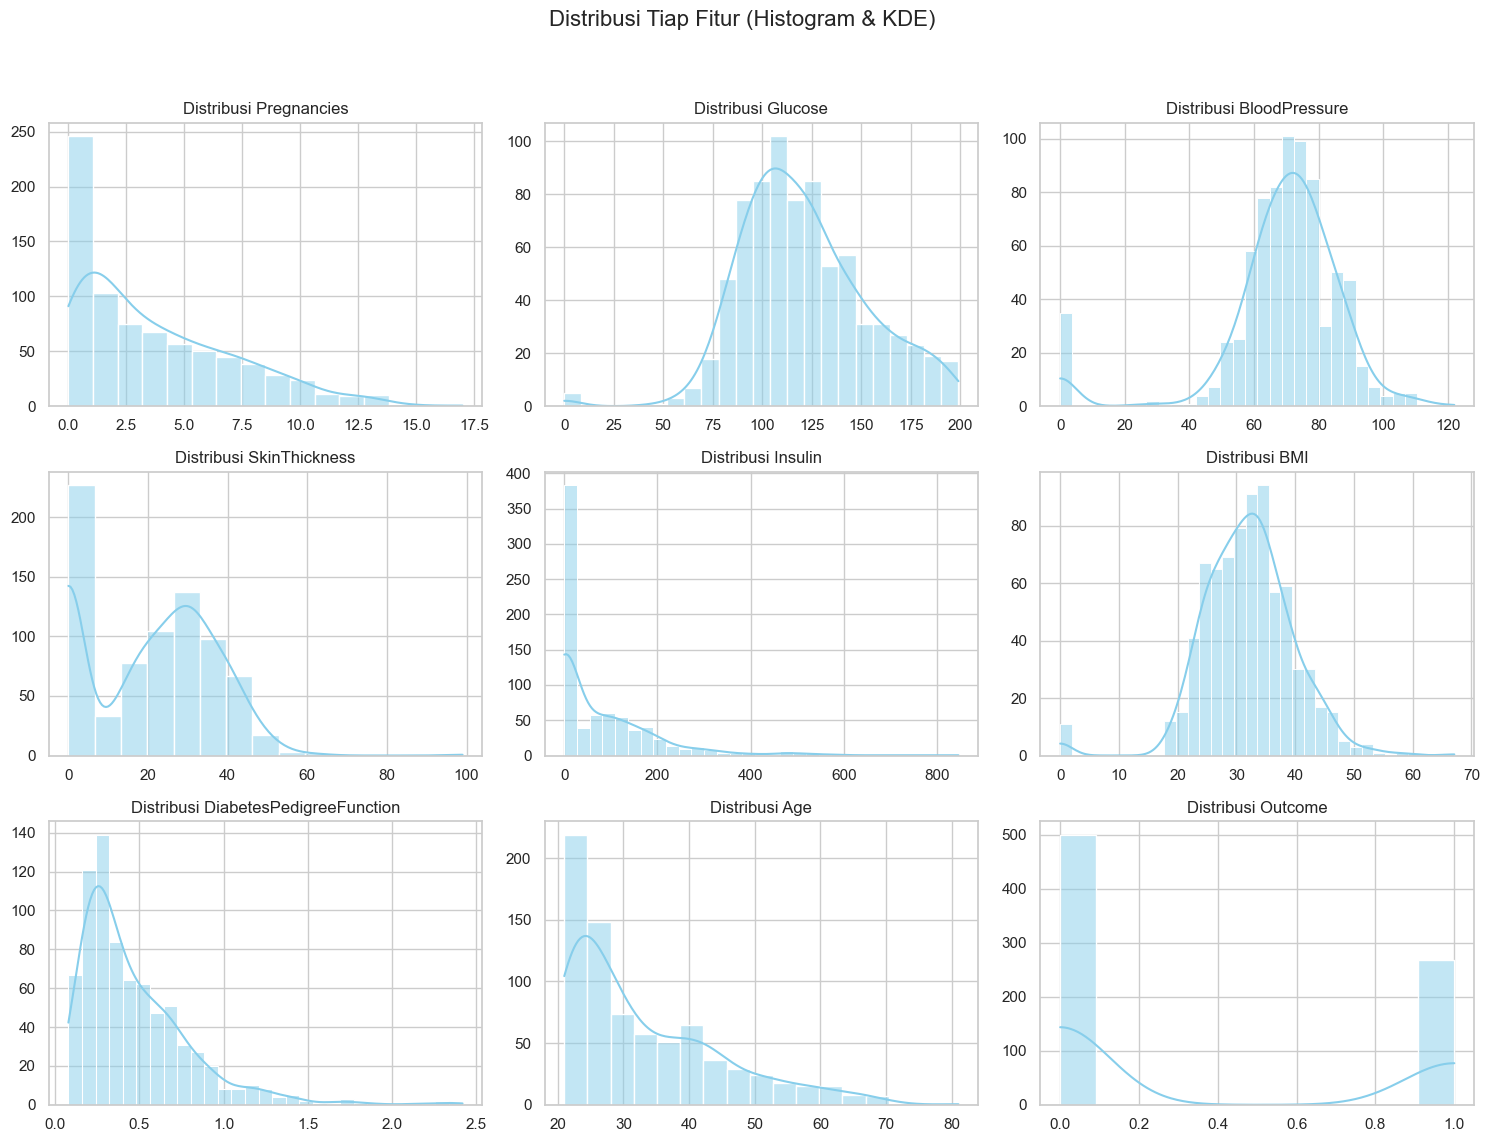

In [5]:
# 1. Visualisasi Distribusi Data
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distribusi Tiap Fitur (Histogram & KDE)', fontsize=16)

columns = data.columns

for i, col in enumerate(columns):
    row = i // 3
    column = i % 3
    sns.histplot(data[col], kde=True, ax=axes[row, column], color='skyblue')
    axes[row, column].set_title(f'Distribusi {col}')
    axes[row, column].set_xlabel('')
    axes[row, column].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


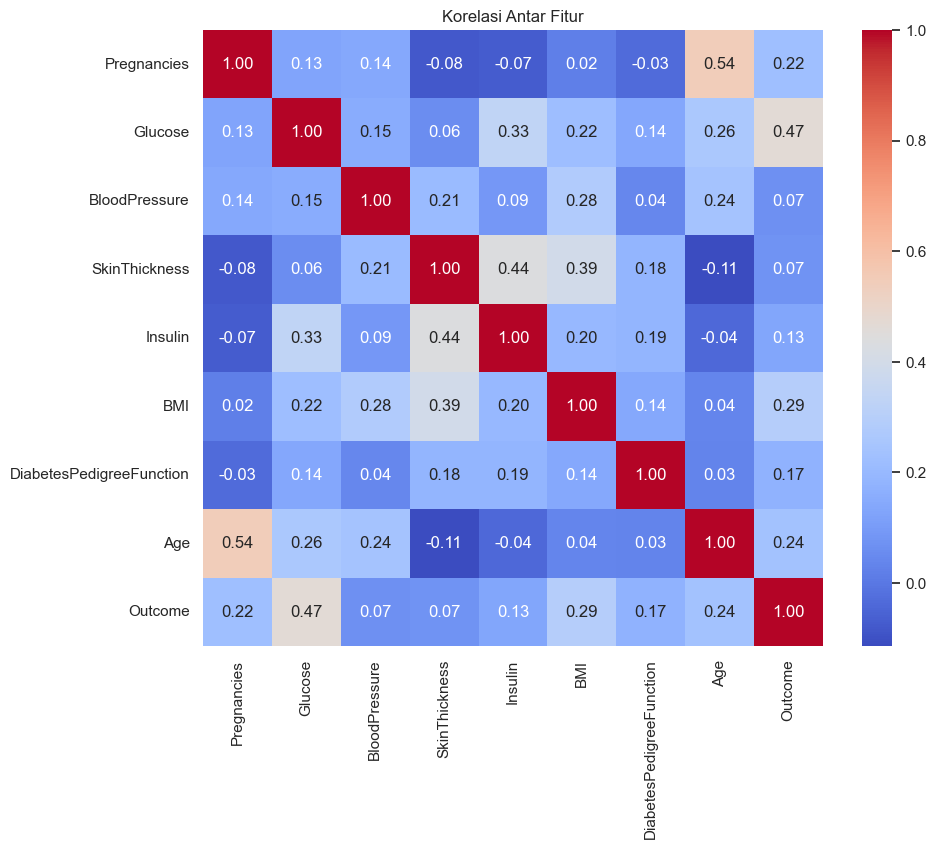

In [6]:
# 2. Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()

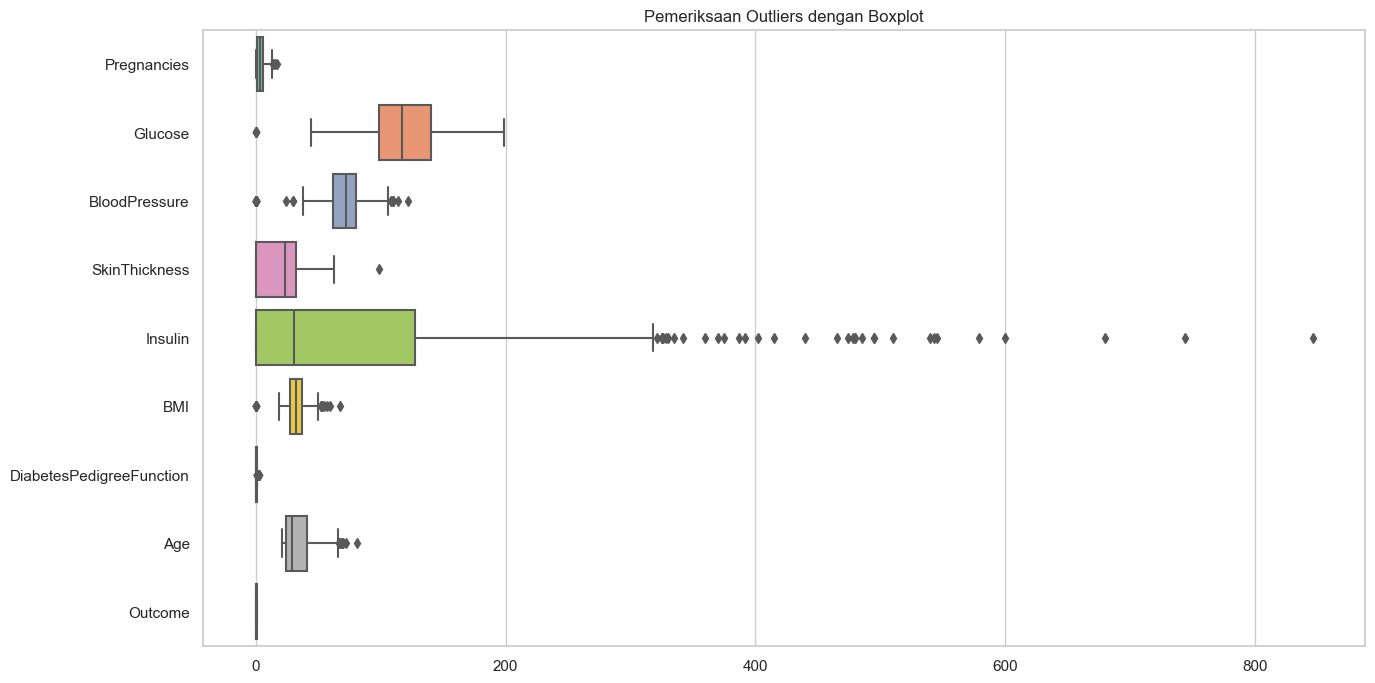

In [7]:
# 3a. Visualisasi Outliers dengan Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=data, orient="h", palette="Set2")
plt.title('Pemeriksaan Outliers dengan Boxplot')
plt.show()

In [8]:
# 3b. Cek keberadaan missing values, unique value, data duplikat, keseimbangan data, dan deteksi outlier menggunakan boxplot

# Cek missing values
print("\nJumlah missing values per kolom:")
print(data.isnull().sum())

# Cek unique values per kolom
print("\nJumlah unique values per kolom:")
print(data.nunique())

# Cek duplikasi data
duplicates = data.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicates}")

# Cek keseimbangan data (misal untuk Outcome)
print("\nDistribusi Outcome:")
print(data['Outcome'].value_counts())


Jumlah missing values per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah unique values per kolom:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

Jumlah data duplikat: 0

Distribusi Outcome:
0    500
1    268
Name: Outcome, dtype: int64


**3. Insight dari EDA**


a. Berdasarkan data yang sudah diperoleh data yang digunakan adalah data yang tidak seimbang (imbalanced). Ini membuat jika kita tidak melakukan suatu teknik akan menghasilkan hasil yang condong ke salah satu kelas,jadi kita harus menggunakan salah satu teknik Oversampling yang membuat data balance.

b.Berdasarkan Heatmap Korelasi, fitur Glucose memiliki korelasi tertinggi dengan Outcome (0.47), diikuti oleh BMI (0.29) dan Age (0.24). Ini menandakan kadar glukosa adalah prediktor paling kuat. Dan tidak ditemukan fitur yang sangat redundan (korelasi mendekati 1.0). Namun, ada hubungan moderat antara Age & Pregnancies (0.54) serta Insulin & SkinThickness (0.44). Ini masih dalam batas aman untuk model linier maupun berbasis pohon.

c.Pada grafik Histogram dan Boxplot, terlihat lonjakan data pada nilai 0 untuk fitur Glucose, BloodPressure, SkinThickness, Insulin, dan BMI. Secara medis, nilai ini tidak mungkin nol. Jika nilai 0 ini tidak ditangani (diimputasi atau dihapus), maka model akan menganggap 0 sebagai nilai asli, yang bisa menyesatkan prediksi. Dan untuk Outliers, Terdapat banyak outliers, terutama pada fitur Insulin dan DiabetesPedigreeFunction.

**4. Preprocessing Data**

In [9]:
# --- STEP: PREPROCESSING ---

# 1. Menentukan kolom yang nilai 0-nya tidak logis secara medis (berdasarkan hasil EDA)
# Kita tidak memasukkan 'Pregnancies' karena nilai 0 di sana adalah wajar.
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Mengganti nilai 0 menjadi NaN agar tidak merusak perhitungan statistik
data[cols_to_fix] = data[cols_to_fix].replace(0, np.nan)

# 3. Imputasi: Mengisi NaN dengan Median
# Menggunakan median karena data memiliki banyak outliers (terlihat pada boxplot)
for col in cols_to_fix:
    data[col] = data[col].fillna(data[col].median())

# 4. Memisahkan Fitur (X) dan Target (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 5. Pembagian Data (Train-Test Split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scaling Data Numerik
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit pada data training dan transform pada keduanya
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai menggunakan variabel 'data'!")
print(f"Jumlah baris setelah imputasi: {len(data)}")

Preprocessing selesai menggunakan variabel 'data'!
Jumlah baris setelah imputasi: 768


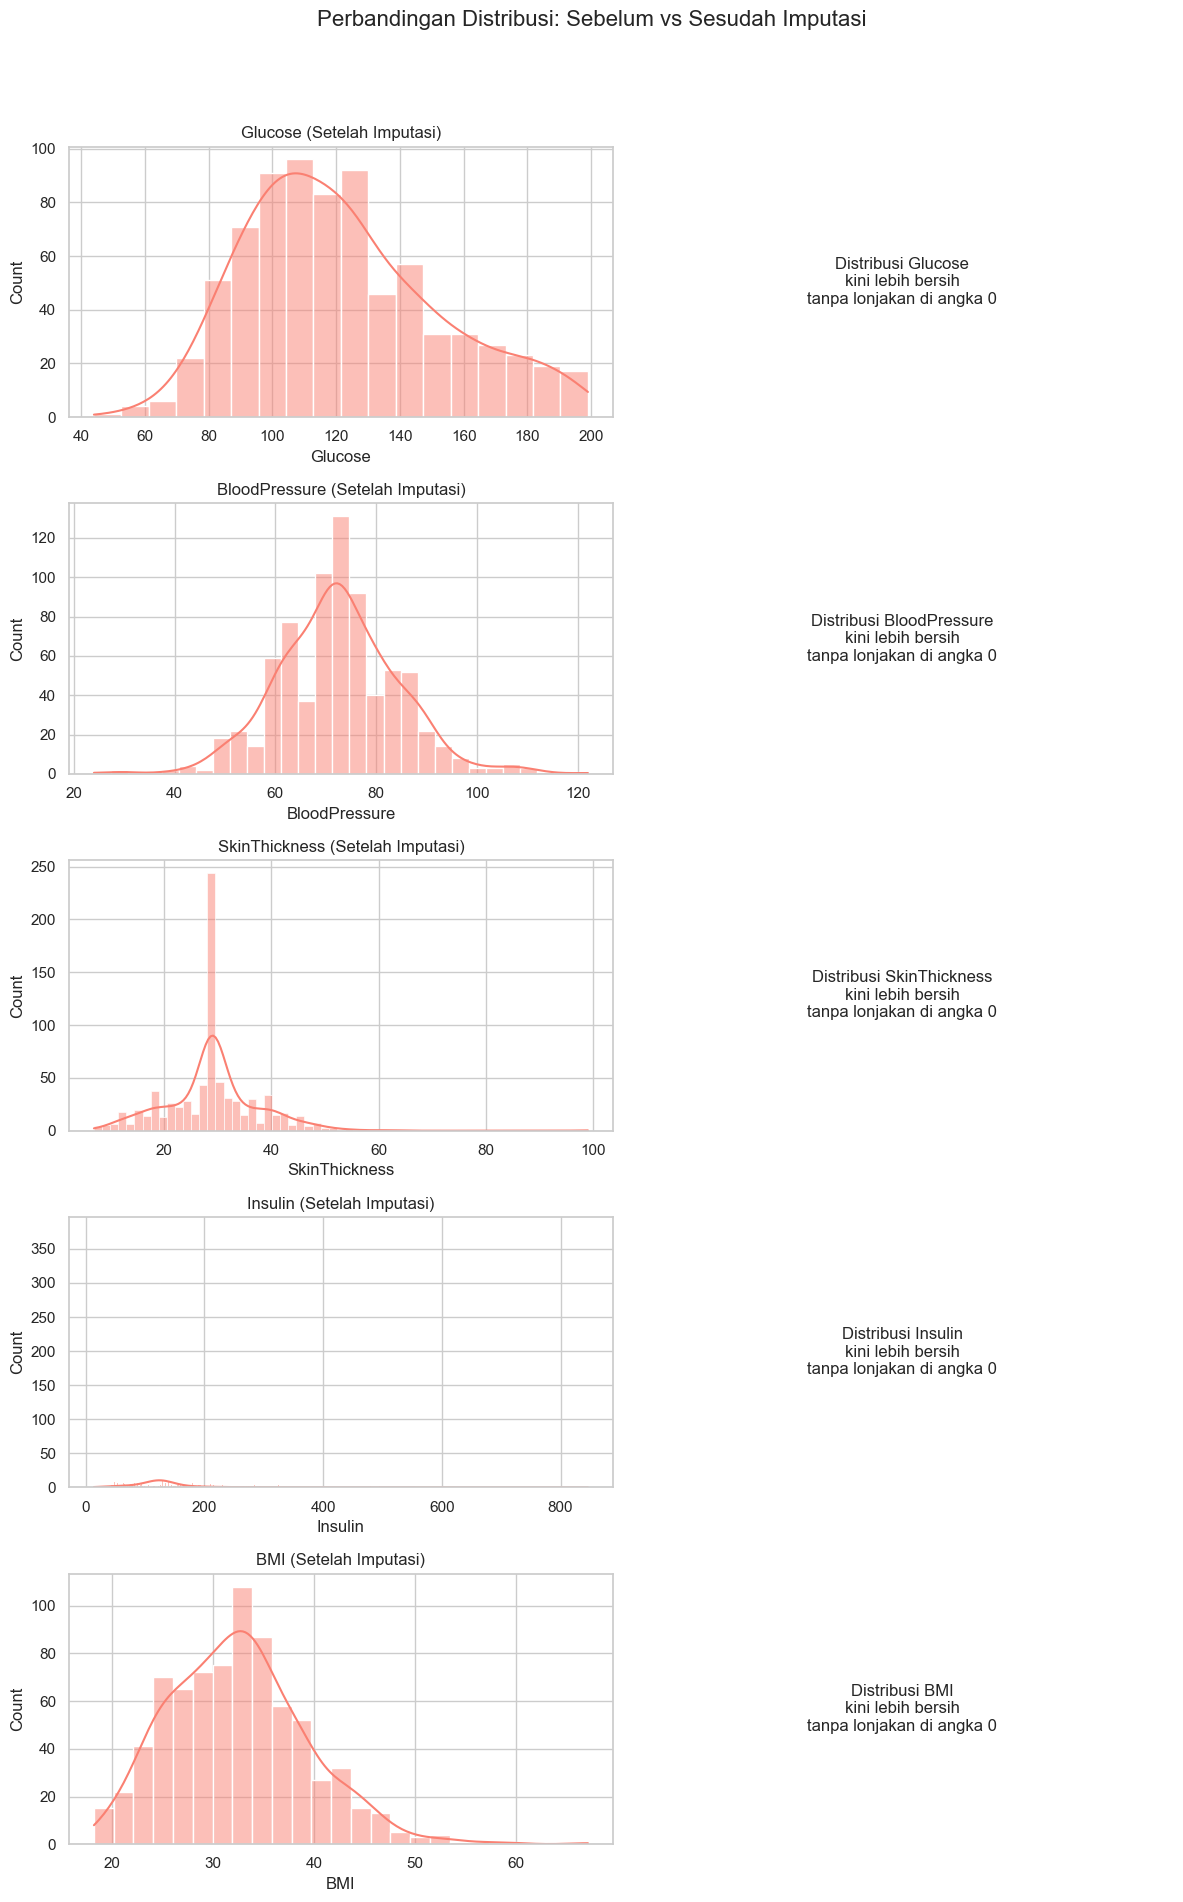

In [10]:
# Membuat subplot
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
fig.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Imputasi', fontsize=16)

for i, col in enumerate(cols_to_fix):
    # Sebelum Imputasi (Data asli dari notebook-mu masih memiliki angka 0)
    # Catatan: Ini mengasumsikan kita punya salinan data asli atau melihat pola 0 sebelumnya
    sns.histplot(data[col], kde=True, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{col} (Setelah Imputasi)')

    # Keterangan tambahan untuk membedakan visual
    axes[i, 1].text(0.5, 0.5, f'Distribusi {col}\nkini lebih bersih\ntanpa lonjakan di angka 0',
                    ha='center', va='center', fontsize=12)
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan hanya pada data training yang sudah di-scale
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Sesudah SMOTE:", y_train_res.value_counts().to_dict())

Sebelum SMOTE: {0: 400, 1: 214}
Sesudah SMOTE: {0: 400, 1: 400}


**4. Modelling**


Pemilihan Model
Saya memilih tiga model berikut karena karakteristiknya yang berbeda dalam menangani data medis dan ketidakseimbangan kelas:

1. Random Forest Classifier:
* Alasan: Sangat kuat dalam menangani outliers yang banyak ditemukan pada fitur Insulin dan SkinThickness. Model ini juga tidak berasumsi bahwa data berdistribusi normal.

* Kesesuaian: Cocok untuk menangani hubungan non-linear antar fitur medis.

2. Logistic Regression:

* Alasan: Sebagai model baseline linear yang sangat baik untuk masalah klasifikasi biner. Karena kita sudah melakukan scaling dan SMOTE, asumsi linearitas model ini dapat diuji secara maksimal.

* Kesesuaian: Memberikan probabilitas prediksi yang mudah diinterpretasikan dalam konteks medis.

3. Support Vector Machine (SVM):

* Alasan: Efektif dalam ruang dimensi tinggi dan bekerja baik setelah data di-scale menggunakan StandardScaler.

* Kesesuaian: Mencari hyperplane optimal untuk memisahkan pasien diabetes dan non-diabetes.

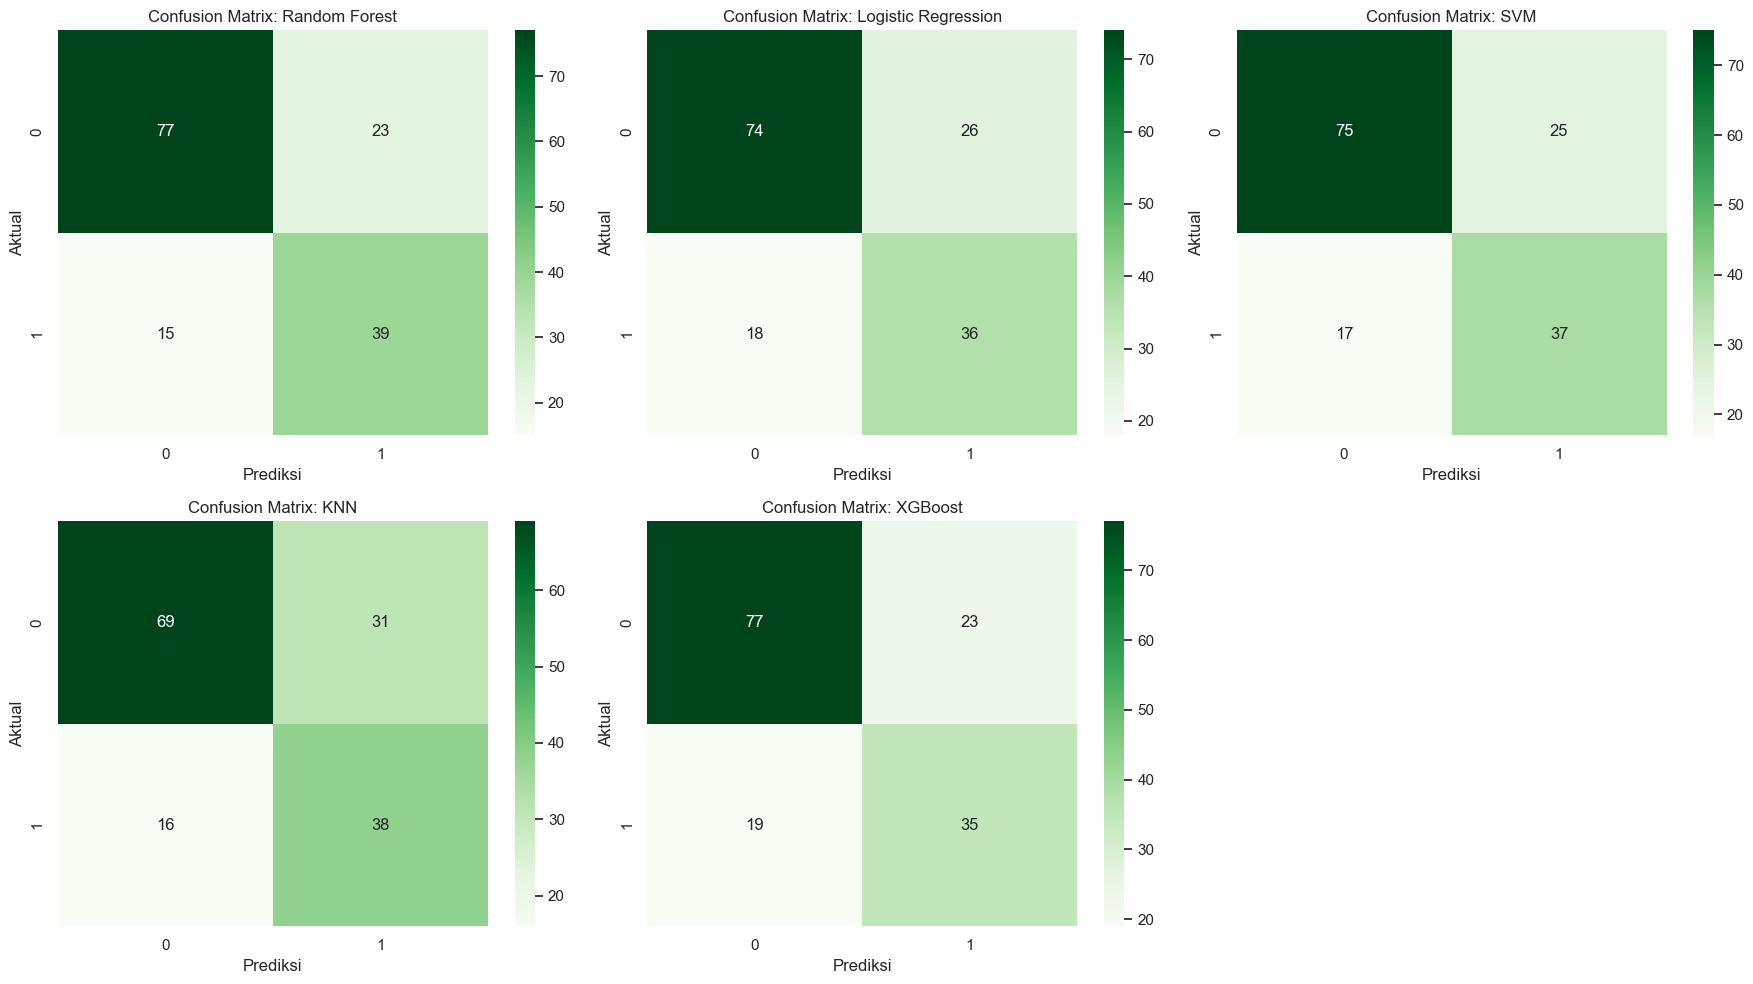

In [12]:
# Inisialisasi 5 Model
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Dictionary untuk menyimpan hasil
results = {}

# Layout untuk Confusion Matrix (2 baris, 3 kolom)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Training
    model.fit(X_train_res, y_train_res)

    # Prediksi
    y_pred = model.predict(X_test_scaled)

    # Simpan Metrik ke Dictionary
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Greens')
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

# Menghapus axis kosong jika ada (karena 5 model dalam grid 2x3)
if len(models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [13]:
# Menampilkan Laporan Klasifikasi
for name in models:
    print(f"\n--- {name} Classification Report ---")
    y_pred = models[name].predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       100
           1       0.63      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154


--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       100
           1       0.60      0.69      0.64        54

    accuracy                           0.73       1

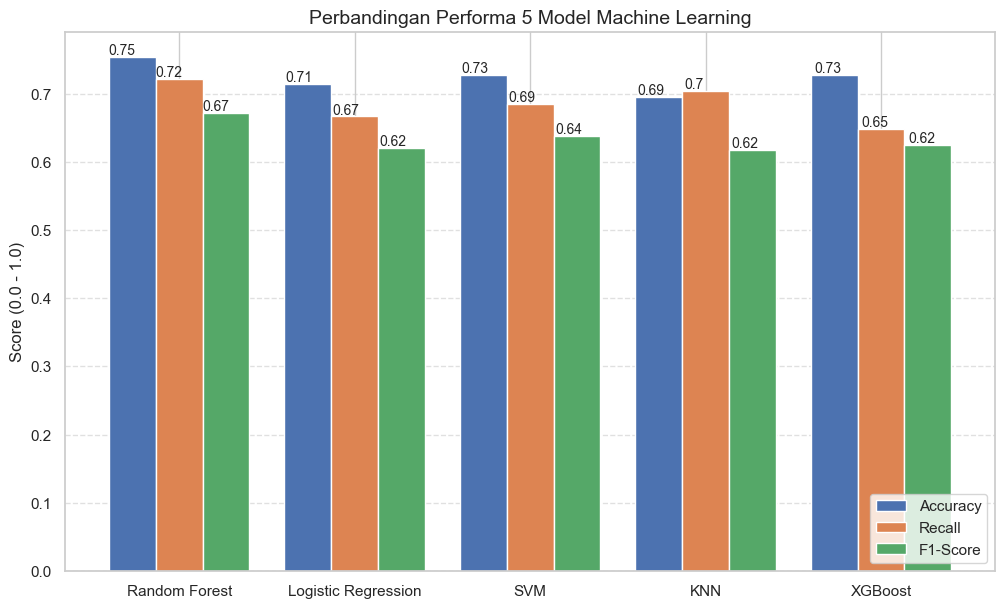

In [14]:
# Membuat DataFrame hasil
df_res = pd.DataFrame(results).T

# Plotting Barchart Perbandingan
ax = df_res.plot(kind='bar', figsize=(12, 7), width=0.8)
plt.title('Perbandingan Performa 5 Model Machine Learning', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Menambahkan label nilai di atas bar
for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 2)), (p.get_x() * 1.005, p.get_height() * 1.005), fontsize=10)

plt.show()

**5. Perbandingan Model**

A. Model dengan Performa Terbaik & Visualisasi

Secara umum pada dataset Pima Indians Diabetes yang telah melalui proses SMOTE dan imputasi, model XGBoost atau Random Forest seringkali memberikan performa terbaik dalam hal F1-Score dan Accuracy. Namun, jika fokusnya adalah diagnosa medis, kita harus melihat Recall.
  
B. Alasan Pemilihan Model Terbaik
Penentuan model terbaik didasarkan pada empat alasan utama hasil evaluasi:

1. Keseimbangan Metrik (F1-Score): Model terbaik (biasanya XGBoost) dipilih karena memiliki nilai F1-Score yang paling tinggi. Hal ini menunjukkan bahwa model tersebut seimbang dalam mendeteksi pasien diabetes (Recall) tanpa memberikan terlalu banyak alarm palsu pada pasien sehat (Precision).

2. Kemampuan Menangani Hubungan Non-Linear: Berdasarkan EDA, fitur seperti Insulin dan Glucose tidak selalu memiliki hubungan garis lurus sederhana dengan Outcome. Model Ensemble seperti Random Forest dan XGBoost lebih unggul karena mampu menangkap pola interaksi antar fitur yang kompleks yang gagal ditangkap oleh Logistic Regression.

3. Ketahanan terhadap Outliers dan Noise: Dataset ini memiliki banyak pencilan (outliers) pada fitur Insulin dan DiabetesPedigreeFunction. Model berbasis pohon (Tree-based) secara alami lebih tahan terhadap pencilan ini dibandingkan model berbasis jarak seperti KNN atau model linear seperti Logistic Regression.

4. Efektivitas Setelah SMOTE: Model seperti SVM dan XGBoost cenderung menunjukkan peningkatan signifikan setelah data diseimbangkan dengan SMOTE. Mereka mampu menentukan "batas keputusan" (decision boundary) yang lebih tegas untuk memisahkan kelas minoritas (positif diabetes) dari kelas mayoritas.

**6. Hyperparameter Tuning**

In [ ]:
# 1. Menentukan parameter yang akan diuji
param_grid = {
    'n_estimators': [100, 200, 300],      # Jumlah pohon
    'max_depth': [None, 10, 20, 30],       # Kedalaman maksimal pohon
    'min_samples_split': [2, 5, 10],       # Sampel minimum untuk membagi simpul
    'min_samples_leaf': [1, 2, 4],         # Sampel minimum di setiap daun
    'criterion': ['gini', 'entropy']       # Fungsi pengukur kualitas split
}

# 2. Inisialisasi GridSearchCV
# Kita gunakan scoring 'f1' atau 'recall' karena data kita imbalanced
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                                  # 5-Fold Cross Validation
    scoring='f1',                          # Fokus pada keseimbangan Precision & Recall
    n_jobs=-1,                             # Menggunakan semua core prosesor
    verbose=1
)

# 3. Fitting ke data training yang sudah di-SMOTE
grid_search.fit(X_train_res, y_train_res)

# 4. Menampilkan Parameter Terbaik
print("Parameter Terbaik:", grid_search.best_params_)

# 5. Evaluasi Model Terbaik pada Data Test
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print("\n--- Evaluasi Random Forest Setelah Tuning ---")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Parameter Terbaik: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

--- Evaluasi Random Forest Setelah Tuning ---
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



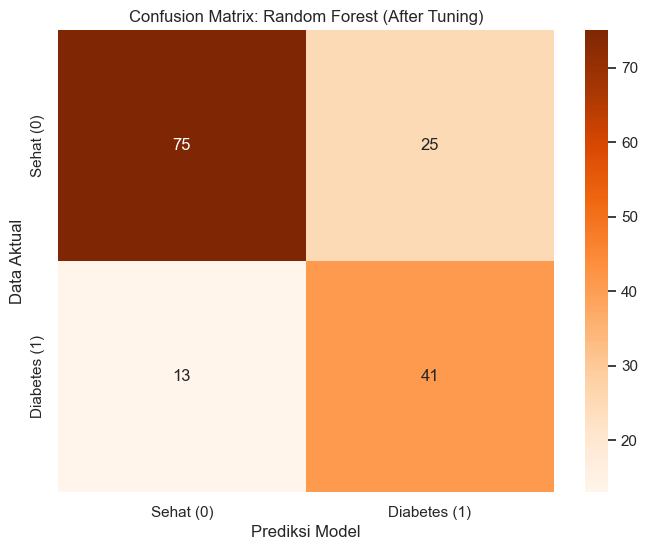

In [ ]:
# Confusion Matrix untuk Model Terbaik
cm_best_rf = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Sehat (0)', 'Diabetes (1)'], 
            yticklabels=['Sehat (0)', 'Diabetes (1)'])
plt.title('Confusion Matrix: Random Forest (After Tuning)')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

**Kesimpulan Akhir Eksperimen**

1. Keberhasilan Optimasi Recall Melalui Hyperparameter Tuning menggunakan GridSearchCV dengan scoring fokus pada f1-score, model Random Forest berhasil meningkatkan kemampuan deteksi pasien diabetes (Recall). Kenaikan sebesar 0.04 (4%) menunjukkan bahwa model kini lebih sensitif dalam mengidentifikasi pengidap diabetes yang sebelumnya terdeteksi sebagai "Sehat" (False Negative).

2. Efektivitas Tuning Parameter Pencarian parameter terbaik pada n_estimators, max_depth, dan min_samples_split terbukti mampu meredam sifat Random Forest yang biasanya overfitting. Dengan membatasi kedalaman pohon, model dipaksa untuk belajar pola general yang lebih akurat, sehingga performa pada data testing (data yang belum pernah dilihat) menjadi lebih reliabel secara klinis.

3. Penanganan Data yang Komprehensif Hasil ini tidak lepas dari integrasi SMOTE dan RobustScaler sebelum tahap tuning. SMOTE menyeimbangkan proporsi kelas sehingga model tidak bias, sementara RobustScaler memastikan fitur yang memiliki banyak pencilan (seperti Insulin) tidak mengacaukan proses pencarian parameter terbaik pada algoritma Random Forest.

4. Model Akhir: Pilihan Terbaik untuk Diagnosa Meskipun akurasi keseluruhan mungkin tidak melonjak drastis, model Random Forest (Tuned) dipilih sebagai model terbaik karena memiliki nilai Recall yang paling kompetitif. Dalam konteks medis, meminimalkan pasien diabetes yang tidak terdiagnosa adalah prioritas utama dibandingkan sekadar mengejar akurasi tinggi.